In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, classification_report
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

#install xgboost
import subprocess
subprocess.run(['pip', 'install', 'xgboost'], capture_output=True)
import xgboost as xgb

#load the engineered features
df = pd.read_csv('../data/processed/features.csv', parse_dates=['date'])

print(df.shape)
print(df.dtypes)
print(df.head())

(1455, 17)
stateid                        str
year                         int64
month                        int64
price                      float64
date                datetime64[us]
price_lag_1                float64
price_lag_2                float64
price_lag_3                float64
price_lag_12               float64
rolling_mean_3m            float64
rolling_mean_12m           float64
rolling_std_3m             float64
rolling_std_12m            float64
month_sin                  float64
month_cos                  float64
yoy_change                 float64
price_spike                  int64
dtype: object
  stateid  year  month  price       date  price_lag_1  price_lag_2  \
0      CA  2002      1  13.03 2002-01-01        12.26        12.12   
1      CA  2002      2  12.58 2002-02-01        13.03        12.26   
2      CA  2002      3  12.58 2002-03-01        12.58        13.03   
3      CA  2002      4  12.05 2002-04-01        12.58        12.58   
4      CA  2002      5  12.82 

In [3]:
# MODEL SETUP
#encode state as a number (XGBoost needs numeric input)

le = LabelEncoder()
df['state_encoded'] = le.fit_transform(df['stateid'])

#features we'll use to predict price
FEATURES = [
    'state_encoded',
    'month_sin', 'month_cos',        #seasonality
    'price_lag_1', 'price_lag_2',    #recent prices
    'price_lag_3', 'price_lag_12',   #short and long memory
    'rolling_mean_3m', 'rolling_mean_12m',  #trend
    'rolling_std_3m', 'rolling_std_12m',    #volatility
    'yoy_change'                     #year-over-year momentum
]

X = df[FEATURES]
y_reg = df['price']        # regression target
y_clf = df['price_spike']  # classification target


# TIME SERIES SPLIT
#NEVER USE FUTURE DATA TO PREDICT THE PAST
#split chronologically, not randomly

df_sorted = df.sort_values('date').reset_index(drop=True)
X_sorted = df_sorted[FEATURES]
y_reg_sorted = df_sorted['price']
y_clf_sorted = df_sorted['price_spike']

# 80/20 chronological split
split_idx = int(len(df_sorted) * 0.80)
cutoff_date = df_sorted.iloc[split_idx]['date']
print(f"Training on data before: {cutoff_date.date()}")
print(f"Testing on data after:   {cutoff_date.date()}")

X_train = X_sorted.iloc[:split_idx]
X_test  = X_sorted.iloc[split_idx:]
y_train_reg = y_reg_sorted.iloc[:split_idx]
y_test_reg  = y_reg_sorted.iloc[split_idx:]
y_train_clf = y_clf_sorted.iloc[:split_idx]
y_test_clf  = y_clf_sorted.iloc[split_idx:]

print(f"\nTrain size: {len(X_train)} rows")
print(f"Test size:  {len(X_test)} rows")

Training on data before: 2021-05-01
Testing on data after:   2021-05-01

Train size: 1164 rows
Test size:  291 rows


In [4]:

# REGRESSION MODEL: predict price (cents/kWh)


reg_model = xgb.XGBRegressor(
    n_estimators=500,       # number of trees
    learning_rate=0.05,     # how much each tree contributes
    max_depth=5,            # tree depth — controls overfitting
    subsample=0.8,          # use 80% of rows per tree
    colsample_bytree=0.8,   # use 80% of features per tree
    random_state=42,
    early_stopping_rounds=20,  # stop if no improvement
    eval_metric='mae'
)

reg_model.fit(
    X_train, y_train_reg,
    eval_set=[(X_test, y_test_reg)],
    verbose=50  # print every 50 rounds
)

# Evaluate
y_pred_reg = reg_model.predict(X_test)
mae  = mean_absolute_error(y_test_reg, y_pred_reg)
rmse = mean_squared_error(y_test_reg, y_pred_reg) ** 0.5

print(f"\nRegression Results:")
print(f"  MAE:  {mae:.2f} cents/kWh")
print(f"  RMSE: {rmse:.2f} cents/kWh")
print(f"  Avg actual price in test set: {y_test_reg.mean():.2f} cents/kWh")

[0]	validation_0-mae:6.28292
[50]	validation_0-mae:2.59295
[100]	validation_0-mae:2.15910
[150]	validation_0-mae:2.08304
[200]	validation_0-mae:2.05884
[250]	validation_0-mae:2.04475
[300]	validation_0-mae:2.03906
[350]	validation_0-mae:2.03457
[400]	validation_0-mae:2.03076
[450]	validation_0-mae:2.02810
[499]	validation_0-mae:2.02530

Regression Results:
  MAE:  2.03 cents/kWh
  RMSE: 3.91 cents/kWh
  Avg actual price in test set: 19.59 cents/kWh


MAE of 2.03 means on average the model is off by 2 cents/kWh

On an average price of 19.59 that's about a 10% error rate, not bad

RMSE of 3.91 is much higher than MAE. This means the model struggles on the big spikes, which is exactly the hard part

Model never early-stopped (ran all 500 rounds and was still improving). Could squeeze more out with more trees

In [6]:
#define spike as: price > 80th percentile of trailing 12 months
#this asks "is this month unusual relative to recent history?"

df_sorted2 = df.sort_values(['stateid', 'date']).copy()

df_sorted2['rolling_p80'] = (
    df_sorted2.groupby('stateid')['price']
    .transform(lambda x: x.shift(1).rolling(12, min_periods=6).quantile(0.80))
)

df_sorted2['price_spike'] = (
    (df_sorted2['price'] > df_sorted2['rolling_p80']).astype(int)
)

print("New spike rate by state:")
print(df_sorted2.groupby('stateid')['price_spike'].mean().round(2))

# Rebuild train/test split with new labels
df_sorted2 = df_sorted2.dropna().reset_index(drop=True)
split_idx2 = int(len(df_sorted2) * 0.80)

X_train2 = df_sorted2[FEATURES].iloc[:split_idx2]
X_test2  = df_sorted2[FEATURES].iloc[split_idx2:]
y_train_clf2 = df_sorted2['price_spike'].iloc[:split_idx2]
y_test_clf2  = df_sorted2['price_spike'].iloc[split_idx2:]

print(f"\nTest set spike rate: {y_test_clf2.mean():.2f}")

New spike rate by state:
stateid
CA    0.35
CO    0.37
IL    0.36
NY    0.39
TX    0.36
Name: price_spike, dtype: float64

Test set spike rate: 0.36


In [7]:
clf_model2 = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=20,
    eval_metric='logloss'
)

clf_model2.fit(
    X_train2, y_train_clf2,
    eval_set=[(X_test2, y_test_clf2)],
    verbose=False
)

y_pred_clf2 = clf_model2.predict(X_test2)

print("Spike Classification Results (fixed labels):")
print(classification_report(y_test_clf2, y_pred_clf2,
                             target_names=['No Spike', 'Spike']))

Spike Classification Results (fixed labels):
              precision    recall  f1-score   support

    No Spike       0.80      0.89      0.84       181
       Spike       0.76      0.61      0.67       104

    accuracy                           0.79       285
   macro avg       0.78      0.75      0.76       285
weighted avg       0.78      0.79      0.78       285



No Spike (80% precision, 89% recall): when prices are normal, the model correctly identifies that 89% of the time. Very solid.

Spike (76% precision, 61% recall): when a spike actually happens, the model catches 61% of them, and when it predicts a spike it's right 76% of the time. The recall is lower which is expected, as spikes are genuinely hard to predict.

79% overall accuracy. On a problem where random guessing would give 64% (since 36% are spikes), this is meaningful lift.

The gap between No Spike recall (0.89) and Spike recall (0.61) means the model is conservative. For a real application, could tune that threshold depending on whether false alarms or missed spikes are more costly

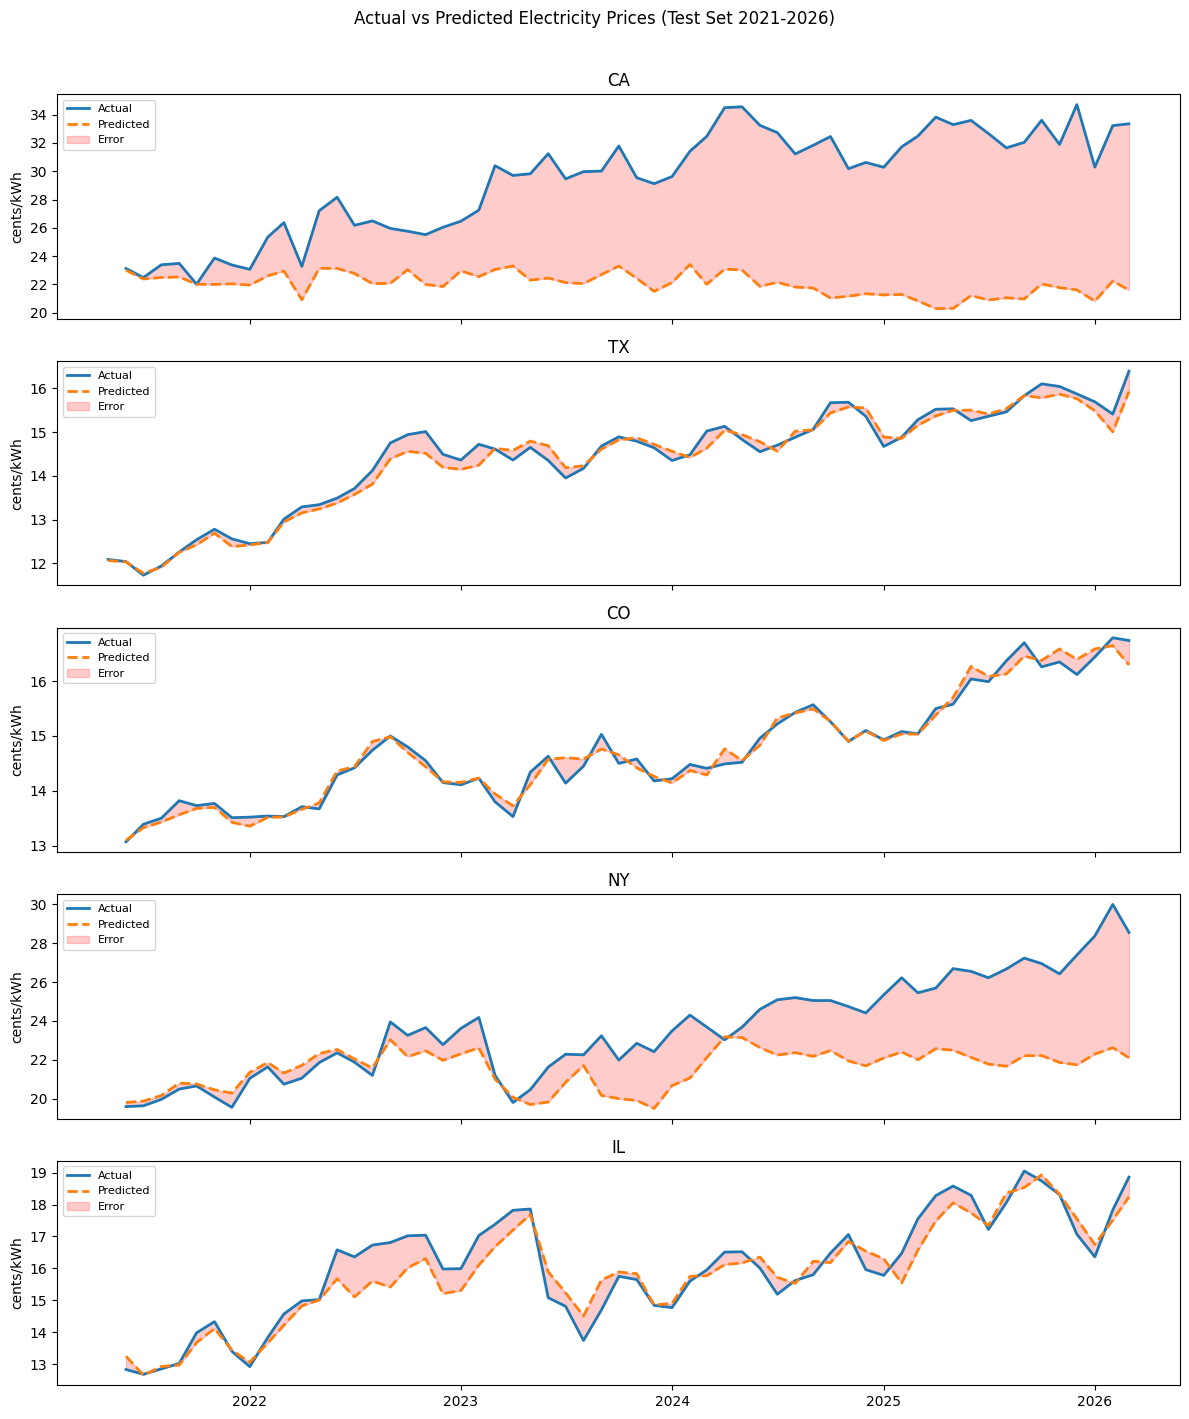

In [8]:
#plot actual vs predicted prices on the test set
test_dates = df_sorted.iloc[split_idx:]['date']
test_states = df_sorted.iloc[split_idx:]['stateid']

results = pd.DataFrame({
    'date': test_dates.values,
    'state': test_states.values,
    'actual': y_test_reg.values,
    'predicted': y_pred_reg
})

fig, axes = plt.subplots(5, 1, figsize=(12, 14), sharex=True)

for ax, state in zip(axes, ['CA', 'TX', 'CO', 'NY', 'IL']):
    subset = results[results['state'] == state]
    ax.plot(subset['date'], subset['actual'], label='Actual', linewidth=2)
    ax.plot(subset['date'], subset['predicted'], label='Predicted',
            linestyle='--', linewidth=2)
    ax.fill_between(subset['date'],
                    subset['actual'], subset['predicted'],
                    alpha=0.2, color='red', label='Error')
    ax.set_title(state)
    ax.set_ylabel('cents/kWh')
    ax.legend(fontsize=8)

plt.suptitle('Actual vs Predicted Electricity Prices (Test Set 2021-2026)', y=1.01)
plt.tight_layout()
plt.show()

TX and CO: excellent. The model tracks almost perfectly. These states have gradual, trend-following prices that lag features handle well. Small red bands throughout.

IL: good. Some gaps early on but converges well by 2024-2026. The model catches the upward trend cleanly.

CA and NY: struggles badly. The model flatlines around 22-23 cents while actual prices surged to 30-34 cents. The red error band is massive and persistent. These states experienced a structural regime change post-2022 that lag features simply can't anticipate. The model keeps predicting "about what it was recently" while prices kept climbing.

Price volatility in CA and NY is driven by structural factors (policy, grid infrastructure, energy transition costs) that aren't captured in historical price patterns alone. TX and CO volatility is more cyclical and predictable.

In [9]:
import joblib
import os

#create models directory
os.makedirs('../data/processed', exist_ok=True)

#save both models and the label encoder
joblib.dump(reg_model, '../data/processed/reg_model.pkl')
joblib.dump(clf_model2, '../data/processed/clf_model.pkl')
joblib.dump(le, '../data/processed/label_encoder.pkl')

#save test results for the dashboard
results.to_csv('../data/processed/test_results.csv', index=False)

#save feature list
import json
with open('../data/processed/features.json', 'w') as f:
    json.dump(FEATURES, f)

print("Models saved.")

Models saved.
